## Google Play Store MArket Analysis

Objective 
- 구글 플레이 앱 시장 구조를 이해
- 평점과 설치 횟수 영향 요인 탐색
- 데이터 품질 이슈 식별과 정제 방향 정의


Dataset 
- googleplaystore.csv
- googleplaystore_user_reviews.csv

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [5]:
apps = pd.read_csv("../data/googleplaystore.csv")
reviews = pd.read_csv("../data/googleplaystore_user_reviews.csv")

print("Apps shape:", apps.shape)
print("Reviews shape:", reviews.shape)

apps.head()

Apps shape: (10841, 13)
Reviews shape: (64295, 5)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
apps.info()
apps.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
dup_cnt = apps.duplicated().sum()
print(dup_cnt)

483


In [8]:
#missing values 
missing = apps.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
dtype: int64

In [9]:
apps[["Installs", "Size", "Price"]].head(10)

,Installs,Size,Price
0,"10,000+",19M,0
1,"500,000+",14M,0
2,"5,000,000+",8.7M,0
3,"50,000,000+",25M,0
4,"100,000+",2.8M,0
5,"50,000+",5.6M,0
6,"50,000+",19M,0
7,"1,000,000+",29M,0
8,"1,000,000+",33M,0
9,"10,000+",3.1M,0


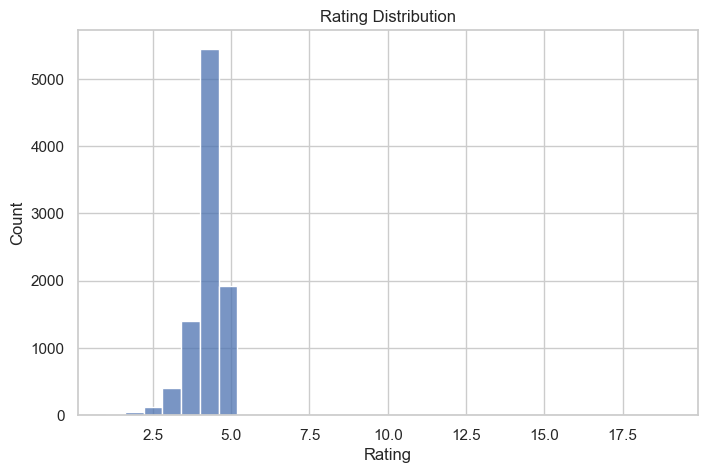

In [10]:
#Rating distribution 
plt.figure()
sns.histplot(apps["Rating"], bins=30)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

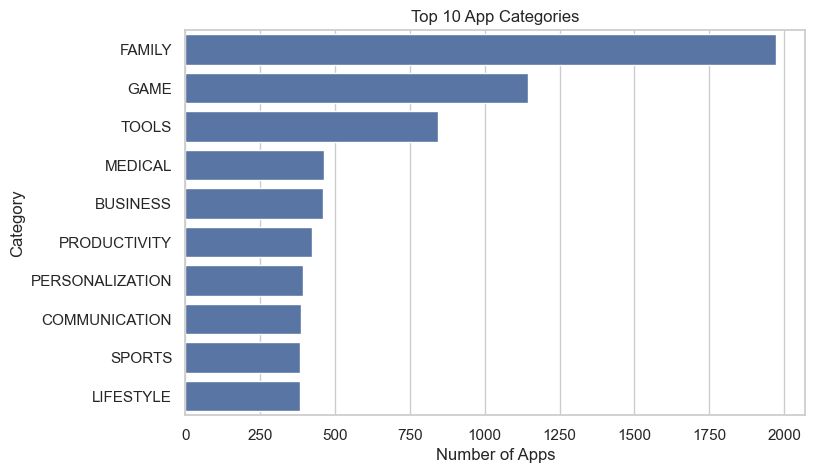

In [11]:
#Top Categories 
top_cat = apps["Category"].value_counts().head(10)

plt.figure()
sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Top 10 App Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

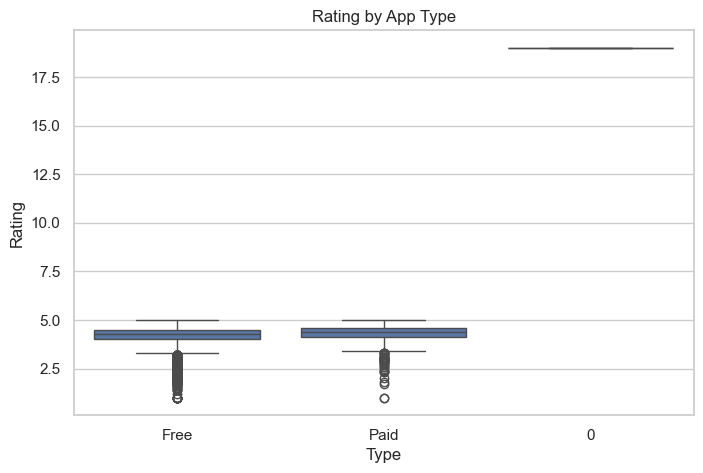

In [12]:
# Free vs Paid Rating 
plt.figure()
sns.boxplot(data=apps, x="Type", y="Rating")
plt.title("Rating by App Type")
plt.xlabel("Type")
plt.ylabel("Rating")
plt.show()


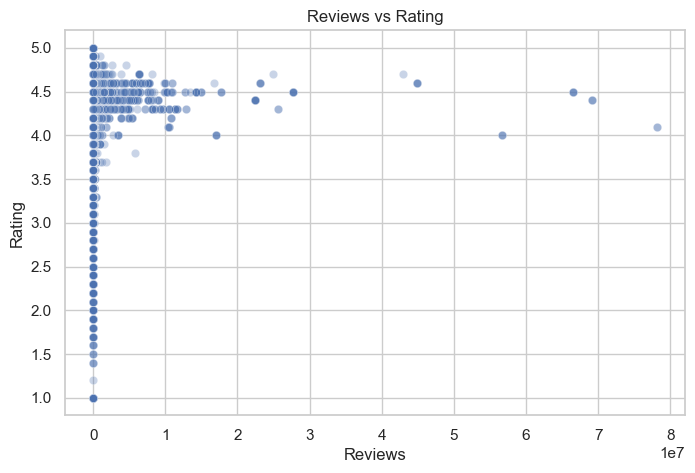

In [13]:
# Reviews vs Rating

apps["Reviews_num"] = pd.to_numeric(apps["Reviews"], errors="coerce")

plt.figure()
sns.scatterplot(
    data=apps,
    x="Reviews_num",
    y="Rating",
    alpha=0.3
)

plt.title("Reviews vs Rating")
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.show()

In [14]:
# Installs Rough Cleaning
apps["Installs_clean"] = (
    apps["Installs"]
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

apps["Installs_clean"] = pd.to_numeric(apps["Installs_clean"], errors="coerce")

apps["Installs_clean"].describe()

count    1.084000e+04
mean     1.546434e+07
std      8.502936e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs_clean, dtype: float64

1. 앱 평점은 4.0~4.5 구간에 집중되어 있음
2. 무료 앱이 유료 앱보다 평점 분산이 큼
3. 리뷰 수가 많은 앱일수록 평점이 안정적
4. Installs, Size, Price 컬럼은 정제가 필요